In [6]:
from enum import Enum
from datetime import datetime
import numpy as np
import matplotlib.pyplot as plt
import scipy
import pandas as pd
import csv
import matplotlib.colors as colors

In [2]:
class OptionBasicType(Enum):
    CALL = "CALL"
    PUT = "PUT"


class OptionExerciseType(Enum):
    EUROPEAN = "EUROPEAN"
    AMERICAN = "AMERICAN"

In [83]:
class EFD:

    def __init__(
        self,
        sigma_min: float,
        sigma_max: float,

        option_basic_type: OptionBasicType,
        option_exercise_type: OptionExerciseType,

        expiry_date: datetime,
        T0: datetime,

        strike_price: float,

        barrier_price: float = None,

        r: float = 0.05,

        delta_t: float = 1 / (365 * 1000),
        delta_s: float = 10,

        dividend_amount: float = 0.0,
        dividend_date: datetime = None,

        verbose: bool = True,
    ) -> None:

        self.sigma_min = sigma_min
        self.sigma_max = sigma_max

        self.option_basic_type = option_basic_type
        self.option_exercise_type = option_exercise_type

        self.expiry_date = expiry_date
        self.T0 = T0

        self.strike_price = strike_price
        self.barrier_price = barrier_price

        self.r = r

        self.delta_t = delta_t
        self.delta_s = delta_s

        self.dividend_amount = dividend_amount
        self.dividend_date = dividend_date

        self.verbose = verbose

        self.initialize_grid()

    # ============================================================
    # PAYOFF
    # ============================================================

    def payoff(self, S):

        if self.option_basic_type == OptionBasicType.CALL:

            return np.maximum(
                S - self.strike_price,
                0.0
            )

        elif self.option_basic_type == OptionBasicType.PUT:

            return np.maximum(
                self.strike_price - S,
                0.0
            )

        else:

            raise ValueError("Invalid option type")

    # ============================================================
    # INITIALIZATION
    # ============================================================

    def initialize_grid(self):

        self.T = (
            self.expiry_date - self.T0
        ).days / 365

        self.M = int(self.T / self.delta_t)

        self.M = max(self.M, 1)

        # --------------------------------------------------------
        # Time convention
        #
        # j = 0  -> maturity
        # j = M  -> today
        #
        # t_j = T - j*dt
        # --------------------------------------------------------

        self.time_values = (
            self.T
            - np.arange(self.M + 1)
            * self.delta_t
        )

        # --------------------------------------------------------
        # Spatial grid
        # --------------------------------------------------------

        if self.barrier_price is None:

            S_max = 3.0 * self.strike_price

            self.N = int(S_max / self.delta_s)

            self.S_values = (
                np.arange(self.N + 1)
                * self.delta_s
            )

        else:

            # Up-and-out CALL

            if (
                self.option_basic_type
                == OptionBasicType.CALL
            ):

                self.N = int(
                    self.barrier_price
                    / self.delta_s
                )

                self.S_values = (
                    np.arange(self.N + 1)
                    * self.delta_s
                )

            # Down-and-out PUT

            else:

                S_max = max(
                    3.0 * self.strike_price,
                    2.0 * self.barrier_price
                )

                self.N = int(
                    (S_max - self.barrier_price)
                    / self.delta_s
                )

                self.S_values = (
                    self.barrier_price
                    + np.arange(self.N + 1)
                    * self.delta_s
                )

        # --------------------------------------------------------
        # Dividend step
        # --------------------------------------------------------

        self.dividend_step = None

        if (
            self.dividend_date is not None
            and self.dividend_amount > 0
        ):

            div_time = (
                self.dividend_date - self.T0
            ).days / 365

            if 0 < div_time < self.T:

                self.dividend_step = int(
                    (self.T - div_time)
                    / self.delta_t
                )

        # --------------------------------------------------------
        # Main grid
        # --------------------------------------------------------

        self.grid = np.zeros(
            (self.N + 1, self.M + 1)
        )

        if (
            self.option_exercise_type
            == OptionExerciseType.AMERICAN
        ):

            self.exercise_grid = np.zeros(
                (self.N + 1, self.M + 1)
            )

        # --------------------------------------------------------
        # Terminal payoff
        # --------------------------------------------------------

        self.grid[:, 0] = self.payoff(
            self.S_values
        )

        # --------------------------------------------------------
        # Boundary conditions
        # --------------------------------------------------------

        tau = (
            self.delta_t
            * np.arange(self.M + 1)
        )

        if self.barrier_price is None:

            if (
                self.option_basic_type
                == OptionBasicType.CALL
            ):

                self.grid[0, :] = 0.0

                self.grid[self.N, :] = (
                    self.S_values[-1]
                    - self.strike_price
                    * np.exp(-self.r * tau)
                )

            else:

                self.grid[self.N, :] = 0.0

                self.grid[0, :] = (
                    self.strike_price
                    * np.exp(-self.r * tau)
                )

        else:

            # Barrier nodes always zero

            self.grid[0, :] = 0.0
            self.grid[self.N, :] = 0.0

        if self.verbose:

            print(f"Grid shape: {self.grid.shape}")
            print(f"M = {self.M}")
            print(f"N = {self.N}")

            if self.dividend_step is not None:

                print(
                    f"Dividend step = "
                    f"{self.dividend_step}"
                )

                print(
                    f"Dividend time = "
                    f"{self.time_values[self.dividend_step]}"
                )

    # ============================================================
    # DISCRETE DIVIDEND
    # ============================================================

    def apply_discrete_dividend(
        self,
        column,
        dividend_amount
    ):

        """
        Backward jump condition.

        Ex-dividend:

            S_after = S_before - D

        Therefore:

            V_before(S)
            =
            V_after(S - D)

        Backward induction:
            interpolate at S + D
        """

        shifted_values = np.interp(
            self.S_values + dividend_amount,
            self.S_values,
            column,
            left=column[0],
            right=column[-1]
        )

        return shifted_values

    # ============================================================
    # BARRIER CONDITION
    # ============================================================

    def apply_barrier_condition(
        self,
        column
    ):

        if self.barrier_price is None:

            return column

        if (
            self.option_basic_type
            == OptionBasicType.CALL
        ):

            knocked = (
                self.S_values
                >= self.barrier_price
            )

        else:

            knocked = (
                self.S_values
                <= self.barrier_price
            )

        column[knocked] = 0.0

        return column

    # ============================================================
    # MAIN FD LOOP
    # ============================================================

    def calculate_grid(self):

        S_arr = self.S_values[1:-1]

        i_eff = S_arr / self.delta_s

        for j in range(1, self.M + 1):

            prev_col = self.grid[:, j - 1]

            # ----------------------------------------------------
            # Gamma
            # ----------------------------------------------------

            gamma = (
                prev_col[2:]
                - 2.0 * prev_col[1:-1]
                + prev_col[:-2]
            ) / (self.delta_s ** 2)

            # ----------------------------------------------------
            # Uncertain volatility
            # ----------------------------------------------------

            sigma = np.where(
                gamma > 0,
                self.sigma_max,
                self.sigma_min
            )

            # ----------------------------------------------------
            # Explicit FD coefficients
            # ----------------------------------------------------

            p_u = 0.5 * self.delta_t * (
                sigma**2 * i_eff**2
                + self.r * i_eff
            )

            p_m = 1.0 - self.delta_t * (
                sigma**2 * i_eff**2
                + self.r
            )

            p_d = 0.5 * self.delta_t * (
                sigma**2 * i_eff**2
                - self.r * i_eff
            )

            # ----------------------------------------------------
            # CONTINUATION VALUE
            # ----------------------------------------------------

            continuation = (

                p_u * prev_col[2:]
                + p_m * prev_col[1:-1]
                + p_d * prev_col[:-2]

            )

            # temporary column

            current_col = np.zeros(self.N + 1)

            current_col[1:-1] = continuation

            # ----------------------------------------------------
            # Dividend jump
            #
            # apply AFTER PDE step
            # BEFORE exercise decision
            # ----------------------------------------------------

            if (
                self.dividend_step is not None
                and j == self.dividend_step
            ):

                current_col = (
                    self.apply_discrete_dividend(
                        current_col,
                        self.dividend_amount
                    )
                )

            # ----------------------------------------------------
            # Barrier condition
            # ----------------------------------------------------

            current_col = (
                self.apply_barrier_condition(
                    current_col
                )
            )

            # ----------------------------------------------------
            # Store continuation value
            # ----------------------------------------------------

            self.grid[:, j] = current_col

            # ----------------------------------------------------
            # American early exercise
            # ----------------------------------------------------

            if (
                self.option_exercise_type
                == OptionExerciseType.AMERICAN
            ):

                intrinsic = self.payoff(S_arr)

                continuation_value = (
                    self.grid[1:-1, j].copy()
                )

                exercise = (
                    intrinsic
                    > continuation_value
                )

                self.exercise_grid[1:-1, j] = (
                    exercise.astype(float)
                )

                # American projection

                self.grid[1:-1, j] = np.maximum(
                    continuation_value,
                    intrinsic
                )

    # ============================================================
    # OPTION PRICE
    # ============================================================

    def get_option_price(
        self,
        S0
    ):

        if self.barrier_price is None:

            i = int(S0 / self.delta_s)

        else:

            if (
                self.option_basic_type
                == OptionBasicType.CALL
            ):

                i = int(
                    S0 / self.delta_s
                )

            else:

                i = int(
                    (S0 - self.barrier_price)
                    / self.delta_s
                )

        if i < 0 or i > self.N:

            raise ValueError(
                "S0 outside grid"
            )

        return self.grid[i, self.M]

    # ============================================================
    # OUTPUT
    # ============================================================

    def get_option_prices_T0(self):

        return (
            self.S_values,
            self.grid[:, -1]
        )

In [90]:
european_call_uvm = EFD(
    sigma_min=0.2,
    sigma_max=0.3,
    option_basic_type=OptionBasicType.CALL,
    option_exercise_type=OptionExerciseType.EUROPEAN,
    expiry_date=datetime(2026, 12, 31),
    T0=datetime(2026, 1, 1),
    strike_price=3200,
    barrier_price=3600,
    
    delta_t=1/(365*1000),
    delta_s=10,

    dividend_amount=300,
    dividend_date=datetime(2026, 6, 30),

    verbose=True
)

european_call_uvm.calculate_grid()


Grid shape: (361, 364001)
M = 364000
N = 360
Dividend step = 184000
Dividend time = 0.4931506849315068


In [91]:
european_put_uvm = EFD(
    sigma_min=0.2,
    sigma_max=0.3,
    option_basic_type=OptionBasicType.PUT,
    option_exercise_type=OptionExerciseType.EUROPEAN,
    expiry_date=datetime(2026, 12, 31),
    T0=datetime(2026, 1, 1),
    strike_price=3200,
    barrier_price=2800,
    
    delta_t=1/(365*1000),
    delta_s=10,

    dividend_amount=300,
    dividend_date=datetime(2026, 6, 30),

    verbose=True
)

european_put_uvm.calculate_grid()

Grid shape: (681, 364001)
M = 364000
N = 680
Dividend step = 184000
Dividend time = 0.4931506849315068


In [92]:
american_call_uvm = EFD(
    sigma_min=0.2,
    sigma_max=0.3,
    option_basic_type=OptionBasicType.CALL,
    option_exercise_type=OptionExerciseType.AMERICAN,
    expiry_date=datetime(2026, 12, 31),
    T0=datetime(2026, 1, 1),
    strike_price=3200,
    barrier_price=3600,
    
    delta_t=1/(365*1000),
    delta_s=10,

    dividend_amount=300,
    dividend_date=datetime(2026, 6, 30),

    verbose=True
)

american_call_uvm.calculate_grid()

Grid shape: (361, 364001)
M = 364000
N = 360
Dividend step = 184000
Dividend time = 0.4931506849315068


In [93]:
american_put_uvm = EFD(
    sigma_min=0.2,
    sigma_max=0.3,
    option_basic_type=OptionBasicType.PUT,
    option_exercise_type=OptionExerciseType.AMERICAN,
    expiry_date=datetime(2026, 12, 31),
    T0=datetime(2026, 1, 1),
    strike_price=3200,
    barrier_price=2800,
    
    delta_t=1/(365*1000),
    delta_s=10,

    dividend_amount=300,
    dividend_date=datetime(2026, 6, 30),

    verbose=True
)

american_put_uvm.calculate_grid()

Grid shape: (681, 364001)
M = 364000
N = 680
Dividend step = 184000
Dividend time = 0.4931506849315068


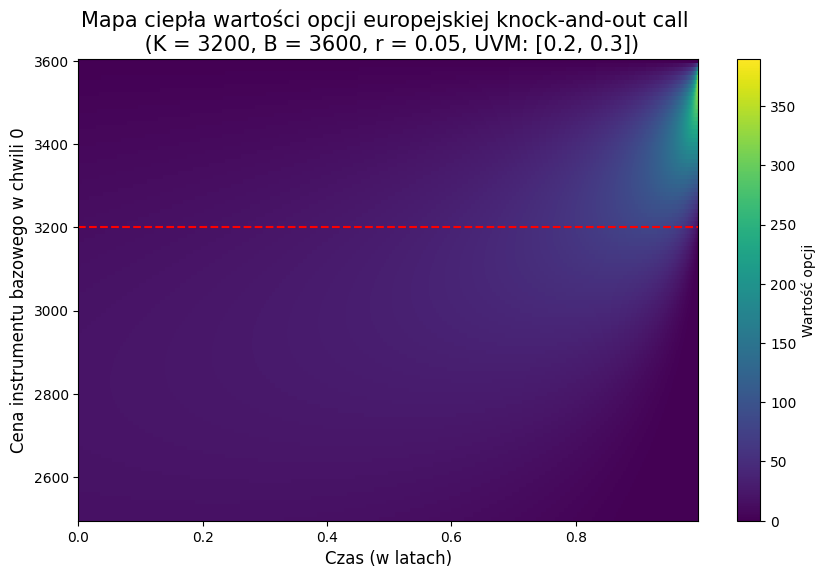

In [ ]:
grid = european_call_uvm.grid
N = european_call_uvm.N
M = european_call_uvm.M
dt = european_call_uvm.delta_t
ds = european_call_uvm.delta_s
strike_price = european_call_uvm.strike_price

time_axis = np.arange(M + 1) * dt
price_axis = np.arange(N + 1) * ds
grid_for_plot = grid[:, ::-1]

fig, ax = plt.subplots(figsize=(10, 6))

clipped_grid = np.maximum(grid_for_plot, 1e-10) 
#norm = colors.LogNorm()

c = ax.pcolormesh(time_axis, price_axis[250:], clipped_grid[250:,:], shading='auto', cmap='viridis')
ax.set_title('Mapa ciepła wartości opcji europejskiej knock-and-out call \n (K = 3200, B = 3600, r = 0.05, UVM: [0.2, 0.3])', fontsize=15)
ax.set_xlabel('Czas (w latach)', fontsize=12)
ax.set_ylabel('Cena instrumentu bazowego w chwili 0', fontsize=12)
ax.axhline(y=strike_price, color='red', linestyle='--', label=f'Cena wykonania: {strike_price}')
fig.colorbar(c, ax=ax, label='Wartość opcji')
plt.savefig('1', bbox_inches='tight', pad_inches=0.3)
plt.show()

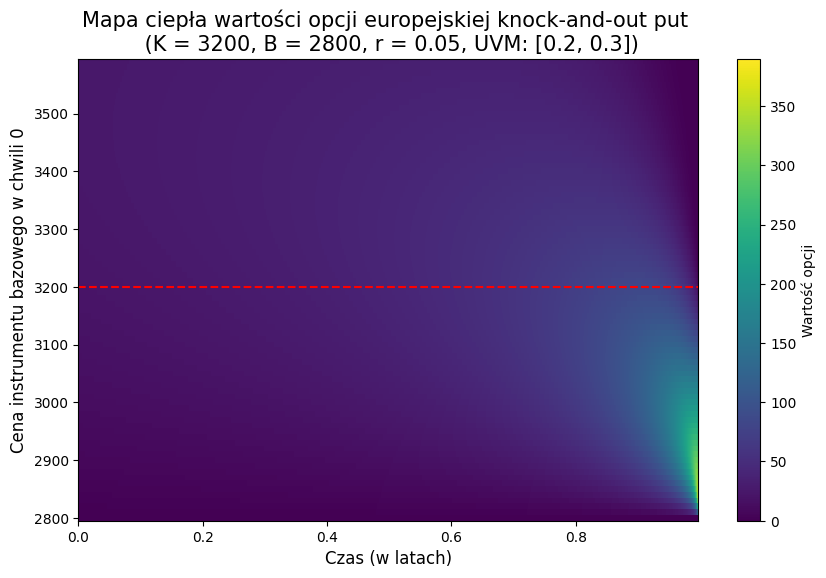

In [25]:
grid = european_put_uvm.grid
N = european_put_uvm.N
M = european_put_uvm.M
dt = european_put_uvm.delta_t
ds = european_put_uvm.delta_s
strike_price = european_put_uvm.strike_price

time_axis = np.arange(M + 1) * dt
price_axis = np.arange(N + 1) * ds + 2800
grid_for_plot = grid[:, ::-1]

fig, ax = plt.subplots(figsize=(10, 6))

clipped_grid = np.maximum(grid_for_plot, 1e-10) 
#norm = colors.LogNorm()

c = ax.pcolormesh(time_axis, price_axis[:80], clipped_grid[:80, :], shading='auto', cmap='viridis')
ax.set_title('Mapa ciepła wartości opcji europejskiej knock-and-out put \n (K = 3200, B = 2800, r = 0.05, UVM: [0.2, 0.3])', fontsize=15)
ax.set_xlabel('Czas (w latach)', fontsize=12)
ax.set_ylabel('Cena instrumentu bazowego w chwili 0', fontsize=12)
ax.axhline(y=strike_price, color='red', linestyle='--', label=f'Cena wykonania: {strike_price}')
#ax.legend(loc='upper left')
fig.colorbar(c, ax=ax, label='Wartość opcji')
plt.savefig('2', bbox_inches='tight', pad_inches=0.3)
plt.show()

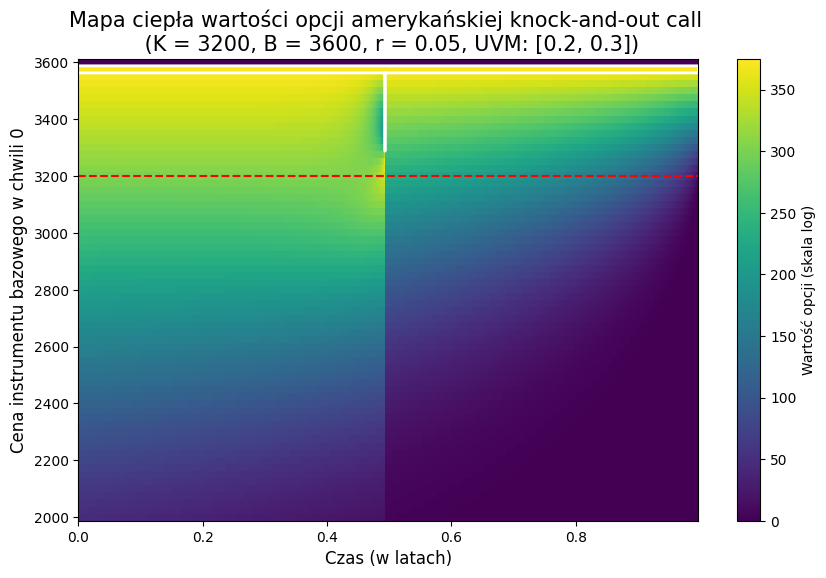

In [89]:
grid = american_call_uvm.grid
N = american_call_uvm.N
M = american_call_uvm.M
dt = american_call_uvm.delta_t
ds = american_call_uvm.delta_s
strike_price = american_call_uvm.strike_price
exercise_for_plot = american_call_uvm.exercise_grid
exercise_for_plot = exercise_for_plot[:, ::-1]

time_axis = np.arange(M + 1) * dt
price_axis = np.arange(N + 1) * ds
grid_for_plot = grid[:, ::-1]

fig, ax = plt.subplots(figsize=(10, 6))

clipped_grid = np.maximum(grid_for_plot, 1e-10) 
#norm = colors.LogNorm()

c = ax.pcolormesh(time_axis, price_axis[80:], clipped_grid[80:,:], shading='auto', cmap='viridis')
ax.set_title('Mapa ciepła wartości opcji amerykańskiej knock-and-out call \n (K = 3200, B = 3600, r = 0.05, UVM: [0.2, 0.3])', fontsize=15)
ax.set_xlabel('Czas (w latach)', fontsize=12)
ax.set_ylabel('Cena instrumentu bazowego w chwili 0', fontsize=12)
ax.axhline(y=strike_price, color='red', linestyle='--', label=f'Strike K = {strike_price}')
#ax.legend(loc='upper left')
#ax.legend(loc='upper left')
CS = ax.contour(
    time_axis, 
    price_axis[80:], 
    exercise_for_plot[80:,:], 
    levels=[0.5], # We want to show the boundary where exercise changes from False to True
    colors='white', 
    linestyles='solid', 
    linewidths=2
)
#ax.plot([], [], color='purple', linestyle='dashdot', linewidth=2, label='Granica wczesnego wykonania')
fig.colorbar(c, ax=ax, label='Wartość opcji (skala log)')

plt.show()

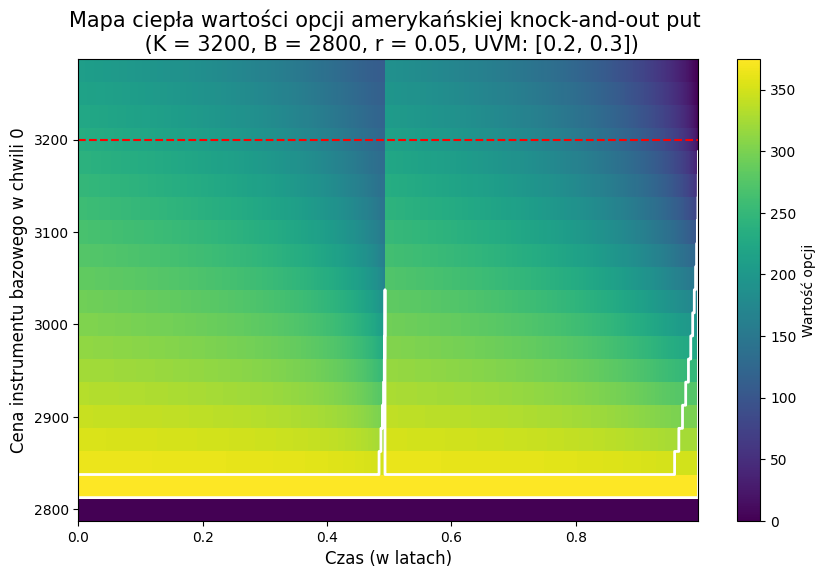

In [87]:
grid = american_put_uvm.grid
N = american_put_uvm.N
M = american_put_uvm.M
dt = american_put_uvm.delta_t
ds = american_put_uvm.delta_s
strike_price = american_put_uvm.strike_price
exercise_for_plot = american_put_uvm.exercise_grid
exercise_for_plot = exercise_for_plot[:, ::-1]

time_axis = np.arange(M + 1) * dt
price_axis = np.arange(N + 1) * ds + 2800
grid_for_plot = grid[:, ::-1]

fig, ax = plt.subplots(figsize=(10, 6))

clipped_grid = np.maximum(grid_for_plot, 1e-10) 
#norm = colors.LogNorm()

c = ax.pcolormesh(time_axis, price_axis[:20], clipped_grid[:20, :], shading='auto', cmap='viridis')
ax.set_title('Mapa ciepła wartości opcji amerykańskiej knock-and-out put \n (K = 3200, B = 2800, r = 0.05, UVM: [0.2, 0.3])', fontsize=15)
ax.set_xlabel('Czas (w latach)', fontsize=12)
ax.set_ylabel('Cena instrumentu bazowego w chwili 0', fontsize=12)
ax.axhline(y=strike_price, color='red', linestyle='--', label=f'Cena wykonania: {strike_price}')
#ax.legend(loc='upper left')
CS = ax.contour(
    time_axis, 
    price_axis[:20], 
    exercise_for_plot[:20, :], 
    levels=[0.5], # We want to show the boundary where exercise changes from False to True
    colors='white', 
    linestyles='solid', 
    linewidths=2
)
fig.colorbar(c, ax=ax, label='Wartość opcji')

plt.show()